# Logistic Regression

`Logistic Regression` is a supervised machine learning algorithm primarily used for `classification` tasks. Unlike linear regression which predicts a continuous output, logistic regression predicts the `probability` that a given input belongs to a certain class. This probability is then mapped to a discrete class label (e.g., 0 or 1, True or False).

Key characteristics:

*   **Classification, not Regression**: It's used to classify data into discrete categories (e.g., spam or not spam, yes or no).
*   **Sigmoid Function**: It uses a sigmoid (or logistic) function to transform its output, ensuring the predicted probabilities are between 0 and 1.
*   **Binary or Multi-class**: While primarily used for binary classification, it can be extended for multi-class problems (e.g., using One-vs-Rest).

##ASSUMPTION FOR LOGISTIC REGRESSION

1- Dependent variable must be categorical in nature <br/>
2- Independent varible must be fully independent<br/>
3- There should be no outlier in data

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder,MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,recall_score,f1_score,accuracy_score,precision_score,classification_report

In [60]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [61]:
# preprocess the data
df.drop('deck',axis=1,inplace=True)
df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

# encoding
le = LabelEncoder()
for i in df.columns:
  if df[i].dtype == 'object' or  df[i].dtype == 'category':
    df[i] = le.fit_transform(df[i])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,True,2,0,False
1,1,1,0,38.0,1,0,71.2833,0,0,2,False,0,1,False
2,1,3,0,26.0,0,0,7.9250,2,2,2,False,2,1,True
3,1,1,0,35.0,1,0,53.1000,2,0,2,False,2,1,False
4,0,3,1,35.0,0,0,8.0500,2,2,1,True,2,0,True


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    int64  
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     891 non-null    int64  
 8   class        891 non-null    int64  
 9   who          891 non-null    int64  
 10  adult_male   891 non-null    bool   
 11  embark_town  891 non-null    int64  
 12  alive        891 non-null    int64  
 13  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(10)
memory usage: 85.4 KB


In [63]:
# split x and y
x = df.drop('survived',axis=1)
y = df['survived']

In [64]:
# train test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)


In [65]:
# call model
model = LogisticRegression()

In [66]:
# train the model
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [67]:
#predict he values
y_pred = model.predict(x_test)

In [70]:
# evalute the model
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred))
print("Accuracy Score:", accuracy_score(y_test,y_pred))
print("Precision Score:", precision_score(y_test,y_pred))
print("Recall Score:", recall_score(y_test,y_pred))
print("F1 Score:", f1_score(y_test,y_pred))
print("\nClassification Report:\n", classification_report(y_test,y_pred))

Confusion Matrix:
 [[106   0]
 [  0  73]]
Accuracy Score: 1.0
Precision Score: 1.0
Recall Score: 1.0
F1 Score: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       106
           1       1.00      1.00      1.00        73

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



Text(95.72222222222221, 0.5, 'Truth')

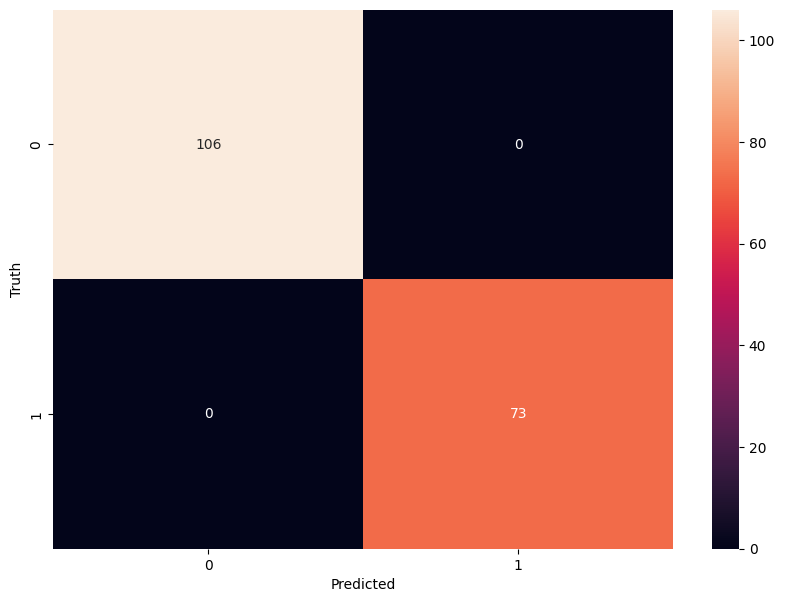

In [71]:
# plot the confusion metrix
plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')